In [1]:
!pip install torch torchvision scikit-learn matplotlib

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import os
import copy
import time

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from pathlib import Path
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

In [3]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cpu


In [4]:
project_root = Path.cwd().parent
data_root = project_root / "dataset" / "processed"

train_dir = data_root / "train"
validation_dir = data_root / "validation"
test_dir = data_root / "test"

print(train_dir)
print(validation_dir)
print(test_dir)

e:\PROJECTS\OralScan-AI\dataset\processed\train
e:\PROJECTS\OralScan-AI\dataset\processed\validation
e:\PROJECTS\OralScan-AI\dataset\processed\test


In [5]:
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.10
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

validation_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [6]:
train_dataset = datasets.ImageFolder(
    train_dir,
    transform=train_transforms
)

validation_dataset = datasets.ImageFolder(
    validation_dir,
    transform=validation_transforms
)

test_dataset = datasets.ImageFolder(
    test_dir,
    transform=validation_transforms
)

print("Class names:", train_dataset.classes)
print("Class mapping:", train_dataset.class_to_idx)

print("Train images:", len(train_dataset))
print("Validation images:", len(validation_dataset))
print("Test images:", len(test_dataset))

Class names: ['CANCER', 'NON CANCER']
Class mapping: {'CANCER': 0, 'NON CANCER': 1}
Train images: 752
Validation images: 95
Test images: 93


In [7]:
batch_size = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

In [8]:
weights = models.EfficientNet_B0_Weights.DEFAULT

model = models.efficientnet_b0(
    weights=weights
)

num_features = model.classifier[1].in_features

model.classifier = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(num_features, len(train_dataset.classes))
)

model = model.to(device)

print(model.classifier)

Sequential(
  (0): Dropout(p=0.3, inplace=False)
  (1): Linear(in_features=1280, out_features=2, bias=True)
)


In [9]:
for parameter in model.features.parameters():
    parameter.requires_grad = False

for parameter in model.classifier.parameters():
    parameter.requires_grad = True

In [10]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    filter(lambda parameter: parameter.requires_grad, model.parameters()),
    lr=0.001
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

In [11]:
def train_model(
    model,
    train_loader,
    validation_loader,
    criterion,
    optimizer,
    scheduler,
    epochs=10
):
    best_model_weights = copy.deepcopy(model.state_dict())
    best_validation_accuracy = 0.0

    history = {
        "train_loss": [],
        "train_accuracy": [],
        "validation_loss": [],
        "validation_accuracy": []
    }

    for epoch in range(epochs):
        print(f"\nEpoch {epoch + 1}/{epochs}")
        print("-" * 40)

        model.train()

        train_loss = 0.0
        train_correct = 0
        train_total = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)

            predictions = outputs.argmax(dim=1)

            train_correct += (
                predictions == labels
            ).sum().item()

            train_total += labels.size(0)

        epoch_train_loss = train_loss / train_total
        epoch_train_accuracy = train_correct / train_total

        model.eval()

        validation_loss = 0.0
        validation_correct = 0
        validation_total = 0

        with torch.no_grad():
            for images, labels in validation_loader:
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                validation_loss += loss.item() * images.size(0)

                predictions = outputs.argmax(dim=1)

                validation_correct += (
                    predictions == labels
                ).sum().item()

                validation_total += labels.size(0)

        epoch_validation_loss = (
            validation_loss / validation_total
        )

        epoch_validation_accuracy = (
            validation_correct / validation_total
        )

        scheduler.step(epoch_validation_loss)

        history["train_loss"].append(epoch_train_loss)
        history["train_accuracy"].append(epoch_train_accuracy)
        history["validation_loss"].append(epoch_validation_loss)
        history["validation_accuracy"].append(
            epoch_validation_accuracy
        )

        print(
            f"Train Loss: {epoch_train_loss:.4f} | "
            f"Train Accuracy: {epoch_train_accuracy:.4f}"
        )

        print(
            f"Validation Loss: {epoch_validation_loss:.4f} | "
            f"Validation Accuracy: {epoch_validation_accuracy:.4f}"
        )

        if epoch_validation_accuracy > best_validation_accuracy:
            best_validation_accuracy = epoch_validation_accuracy
            best_model_weights = copy.deepcopy(
                model.state_dict()
            )

            print("Best model updated.")

    model.load_state_dict(best_model_weights)

    print(
        "\nBest validation accuracy:",
        round(best_validation_accuracy, 4)
    )

    return model, history

In [12]:
from PIL import Image
from pathlib import Path

bad_images = []

for split in ["train", "validation", "test"]:
    split_path = data_root / split

    for class_folder in split_path.iterdir():

        if not class_folder.is_dir():
            continue

        for image_path in class_folder.iterdir():

            try:
                with Image.open(image_path) as image:
                    image.verify()

            except Exception as error:
                bad_images.append((image_path, str(error)))

print("Corrupted images found:", len(bad_images))

for image_path, error in bad_images:
    print(image_path)
    print("Error:", error)

Corrupted images found: 0


In [13]:
deleted_count = 0

for item in bad_images:
    if isinstance(item, tuple):
        image_path = item[0]
    else:
        image_path = item["path"]

    if image_path.exists():
        image_path.unlink()
        deleted_count += 1

print("Deleted invalid images:", deleted_count)

Deleted invalid images: 0


In [14]:
remaining_bad_images = []

for split in ["train", "validation", "test"]:
    split_path = data_root / split

    for image_path in split_path.rglob("*"):
        if not image_path.is_file():
            continue

        try:
            with Image.open(image_path) as image:
                image.convert("RGB").load()

        except Exception as error:
            remaining_bad_images.append((image_path, str(error)))

print("Remaining invalid images:", len(remaining_bad_images))

C:\Users\Naveen Singh Rawat\AppData\Roaming\Python\Python313\site-packages\PIL\Image.py:1054: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Remaining invalid images: 0


In [15]:
trained_model, history = train_model(
    model=model,
    train_loader=train_loader,
    validation_loader=validation_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    epochs=10
)


Epoch 1/10
----------------------------------------
Train Loss: 0.4898 | Train Accuracy: 0.8032
Validation Loss: 0.4198 | Validation Accuracy: 0.8737
Best model updated.

Epoch 2/10
----------------------------------------
Train Loss: 0.3576 | Train Accuracy: 0.8537
Validation Loss: 0.3631 | Validation Accuracy: 0.8632

Epoch 3/10
----------------------------------------
Train Loss: 0.3321 | Train Accuracy: 0.8630
Validation Loss: 0.3373 | Validation Accuracy: 0.8737

Epoch 4/10
----------------------------------------
Train Loss: 0.3087 | Train Accuracy: 0.8803
Validation Loss: 0.3503 | Validation Accuracy: 0.8526

Epoch 5/10
----------------------------------------
Train Loss: 0.2747 | Train Accuracy: 0.8949
Validation Loss: 0.2976 | Validation Accuracy: 0.8947
Best model updated.

Epoch 6/10
----------------------------------------
Train Loss: 0.2820 | Train Accuracy: 0.8856
Validation Loss: 0.3006 | Validation Accuracy: 0.8842

Epoch 7/10
----------------------------------------
T

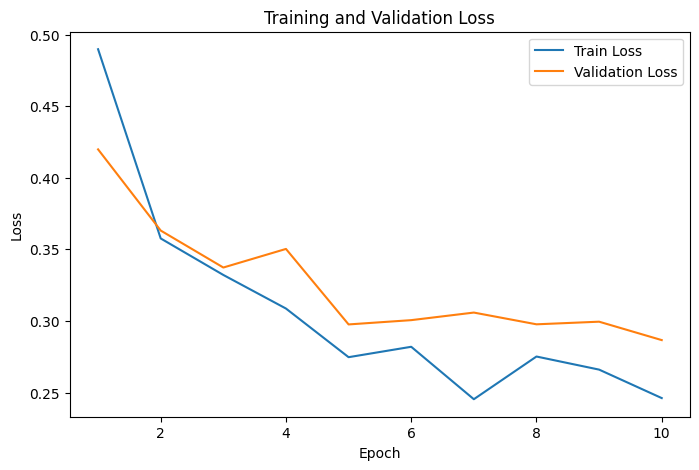

In [16]:
epochs_range = range(
    1,
    len(history["train_loss"]) + 1
)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs_range,
    history["train_loss"],
    label="Train Loss"
)

plt.plot(
    epochs_range,
    history["validation_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

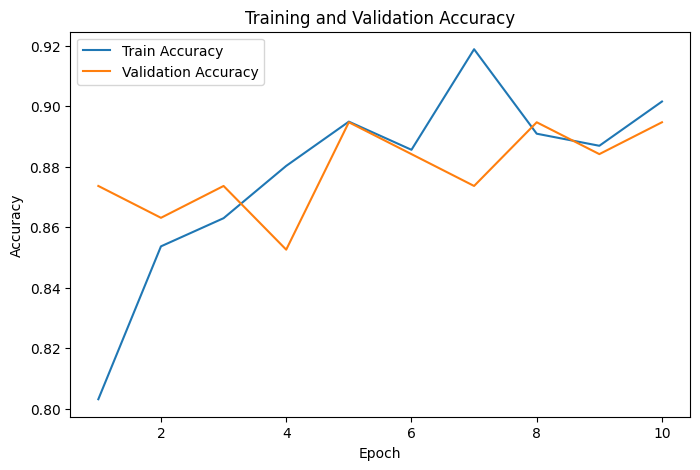

In [17]:
plt.figure(figsize=(8, 5))

plt.plot(
    epochs_range,
    history["train_accuracy"],
    label="Train Accuracy"
)

plt.plot(
    epochs_range,
    history["validation_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.show()

In [18]:
models_dir = project_root / "models"
models_dir.mkdir(exist_ok=True)

model_path = models_dir / "efficientnet_b0_oral_cancer.pth"

torch.save(
    {
        "model_state_dict": trained_model.state_dict(),
        "class_names": train_dataset.classes,
        "class_to_idx": train_dataset.class_to_idx,
        "input_size": 224
    },
    model_path
)

print("Model saved at:", model_path)

Model saved at: e:\PROJECTS\OralScan-AI\models\efficientnet_b0_oral_cancer.pth


In [19]:
import json

class_names_path = models_dir / "class_names.json"

with open(class_names_path, "w") as file:
    json.dump(
        train_dataset.classes,
        file,
        indent=4
    )

print("Class names saved at:", class_names_path)

Class names saved at: e:\PROJECTS\OralScan-AI\models\class_names.json
